In [1]:
library(Seurat)
library(patchwork)
library(tidyverse) 
library(SingleR)
library(celldex)
library(SingleCellExperiment)
library(dplyr)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


In [2]:
data_int <- "../../results/sc_rna/02_preprocess/intermediate"

# Define directories
dir_fig <- "../../results/sc_rna/03_annot/figures"
dir_int <- "../../results/sc_rna/03_annot/intermediate"

# Make sure directories exist
dir.create(dir_fig, recursive = TRUE, showWarnings = FALSE)
dir.create(dir_int, recursive = TRUE, showWarnings = FALSE)

In [3]:
merged_filt <- readRDS(file.path(data_int, "merged_filt.rds"))

# 1. SingleR

In [4]:
ref <- celldex::ImmGenData()  # Mouse

expr_mat <- GetAssayData(merged_filt, assay = "RNA", layer = "data")
labels = ref$label.main

# SingleR
sr_main <- SingleR(
    test = expr_mat,
    ref = ref,
    labels= ref$label.main
)

merged_filt$SingleR_main <- sr_main$labels

In [5]:
head(merged_filt)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,day,RNA_snn_res.0.3,seurat_clusters,refilt_res.0.5,SingleR_main
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<chr>
Day3_AAACCCACAGAAGCGT-1,day03,6319,1899,2.310492,Day3,1,3,3,Macrophages
Day3_AAACCCACAGCTTCGG-1,day03,10846,2735,2.636917,Day3,3,2,2,ILC
Day3_AAACCCATCAACGTGT-1,day03,1426,544,9.186536,Day3,7,6,6,Neutrophils
Day3_AAACCCATCTGCTCTG-1,day03,15119,3407,2.215755,Day3,0,5,5,Macrophages
Day3_AAACGAATCCCGATCT-1,day03,6505,2183,2.997694,Day3,3,2,2,ILC
Day3_AAACGCTAGCGCCCAT-1,day03,6463,1616,2.661303,Day3,1,3,3,Macrophages
Day3_AAAGAACAGTGAGTTA-1,day03,6740,2251,3.635015,Day3,3,2,2,ILC
Day3_AAAGAACAGTGCTAGG-1,day03,20541,3603,5.131201,Day3,6,7,7,T cells
Day3_AAAGAACCAATAGAGT-1,day03,9158,2759,1.976414,Day3,1,0,0,Macrophages


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


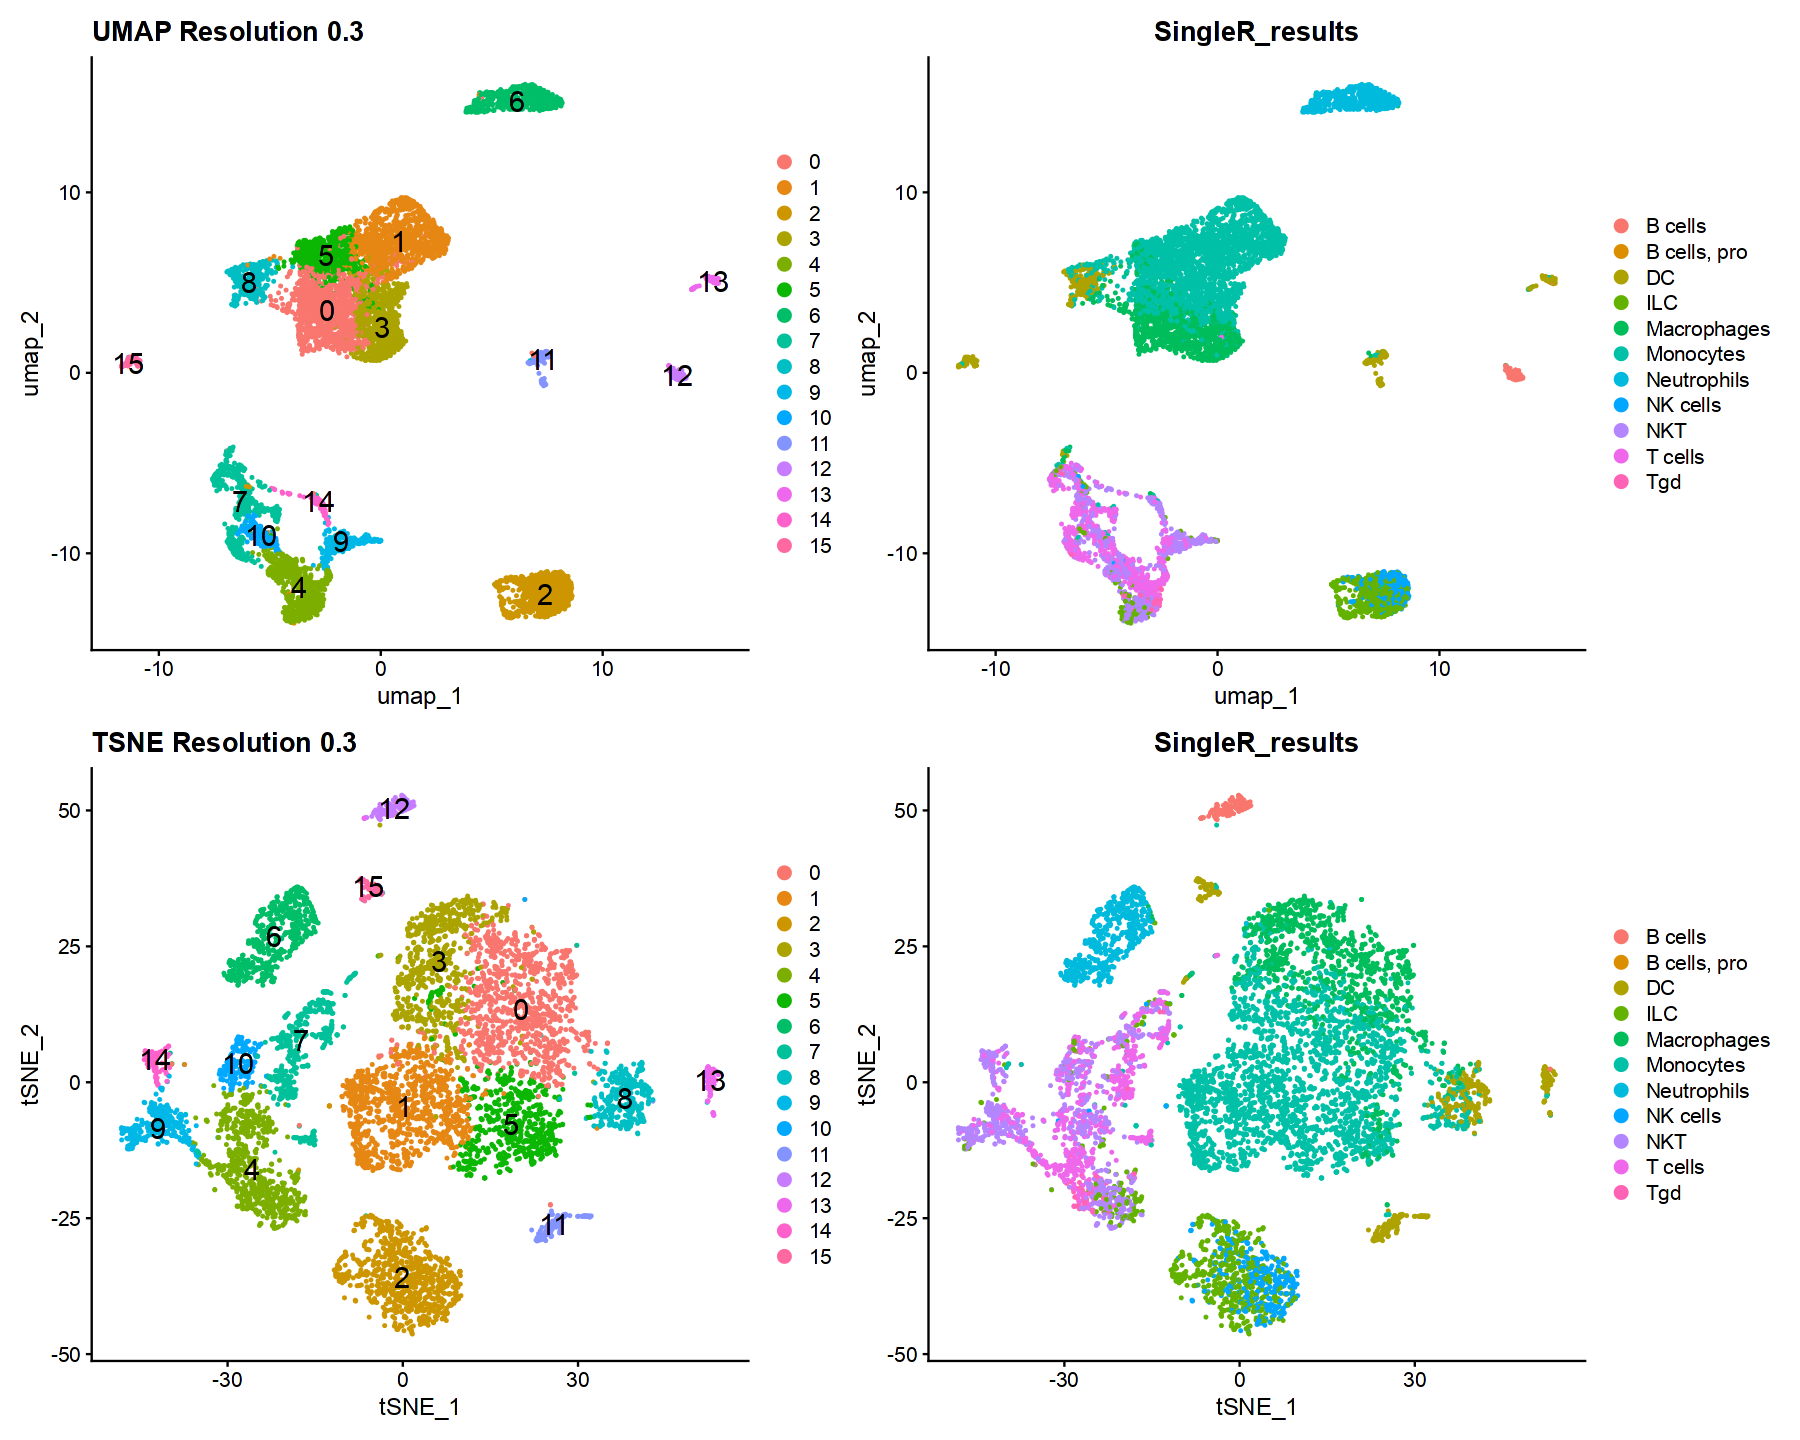

In [6]:
options(repr.plot.width = 15, repr.plot.height = 12)
p1 <- DimPlot(merged_filt, label.size = 6, label=TRUE)+ ggtitle("UMAP Resolution 0.3")
p2 <- DimPlot(merged_filt, label.size = 6, reduction = "tsne", label=TRUE)+ ggtitle("TSNE Resolution 0.3")
p3 <- DimPlot(merged_filt, group.by = 'SingleR_main', label = FALSE, label.size = 6)+ ggtitle("SingleR_results")
p4 <- DimPlot(merged_filt, group.by = 'SingleR_main', reduction = "tsne", label = FALSE, label.size = 6)+ ggtitle("SingleR_results")

(p1+p3)/(p2+p4)

In [7]:
saveRDS(merged_filt, file = file.path(dir_int, "merged_filt_SingleR.rds"))

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’



# 2. Annotation

In [146]:
merged_filt <- readRDS(file.path(dir_int, "merged_filt_SingleR.rds"))

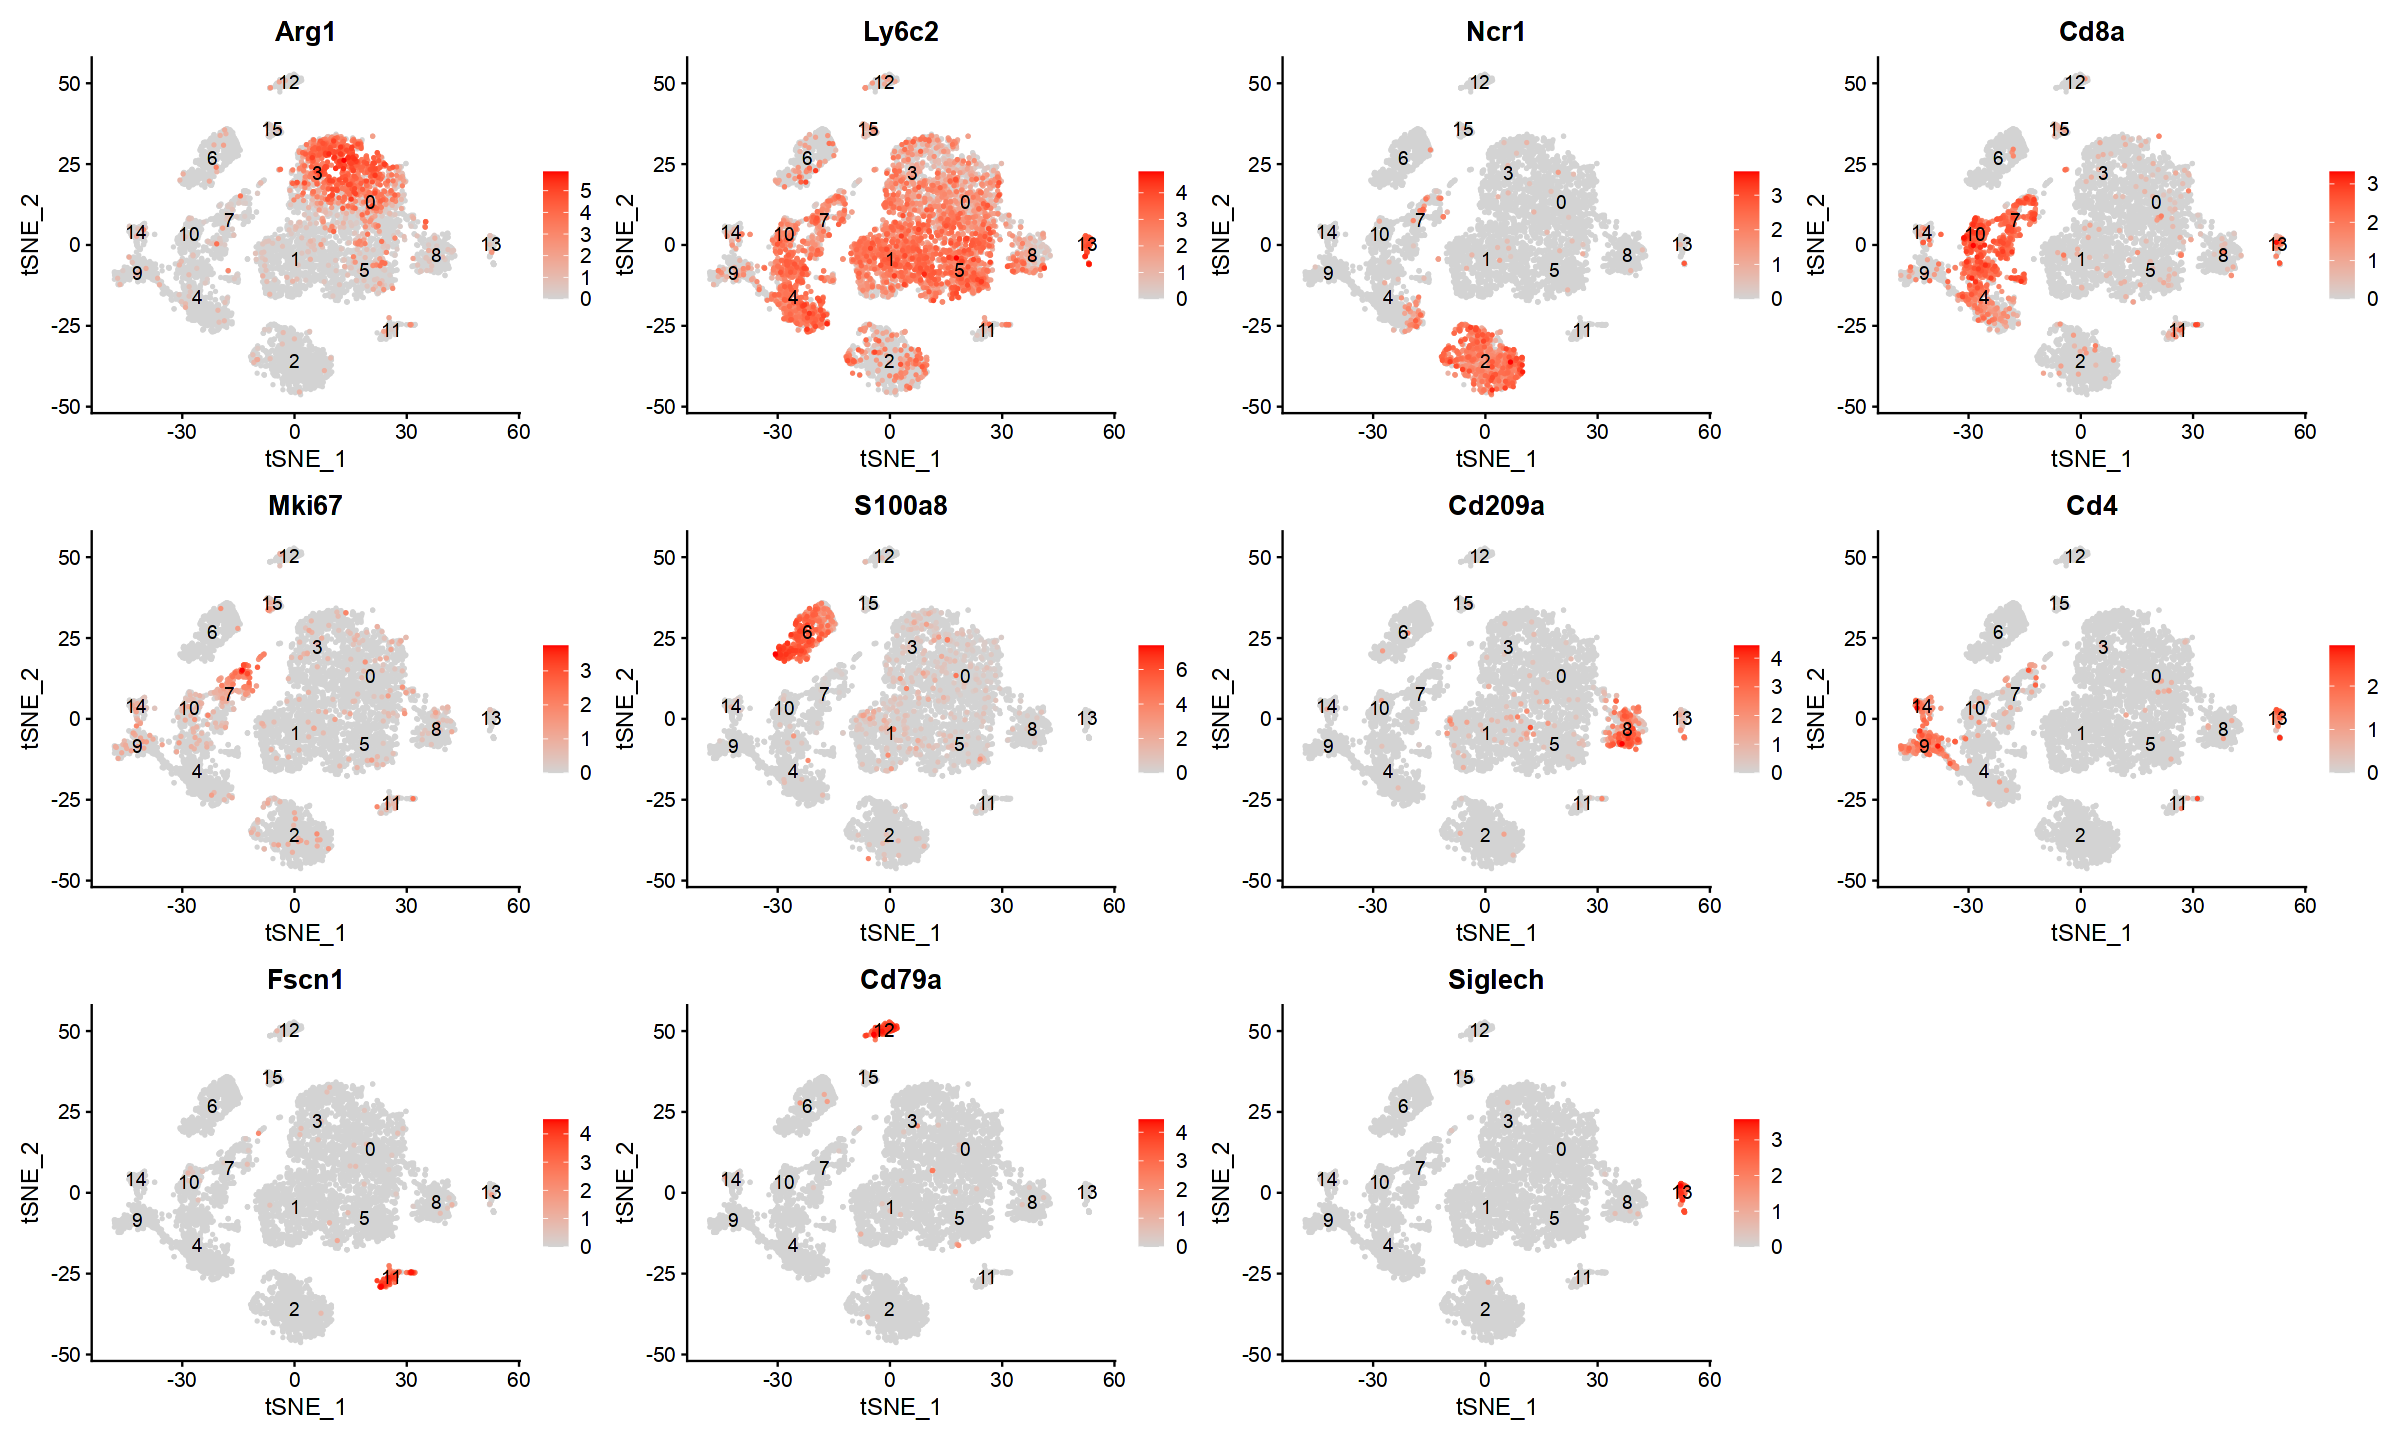

In [147]:
cluster_specific_genes1 <- c(
    "Arg1", #0 Macrophage
    "Ly6c2",#1 Monocyte
    "Ncr1", #2 NK
    "Cd8a", #3 Cd8
    "Mki67",#4 Cycling Cd8
    "S100a8",#5 Neutrophil
    "Cd209a",#6 cDC2 （cDC1（Xcr1）は ＊Itgamは発現してなさそう）  "Xcr1", # cDC1
    "Cd4",   #7 Cd4
    "Fscn1",  #8 cDC3
    "Cd79a", #9 B
    "Siglech" #10 pDC
)

options(repr.plot.width = 20, repr.plot.height = 12)
FeaturePlot(merged_filt, features = cluster_specific_genes1, 
            reduction = "tsne", pt.size=0.3, 
            label=T, order=T, ncol=4, cols = c("lightgrey", "red"))

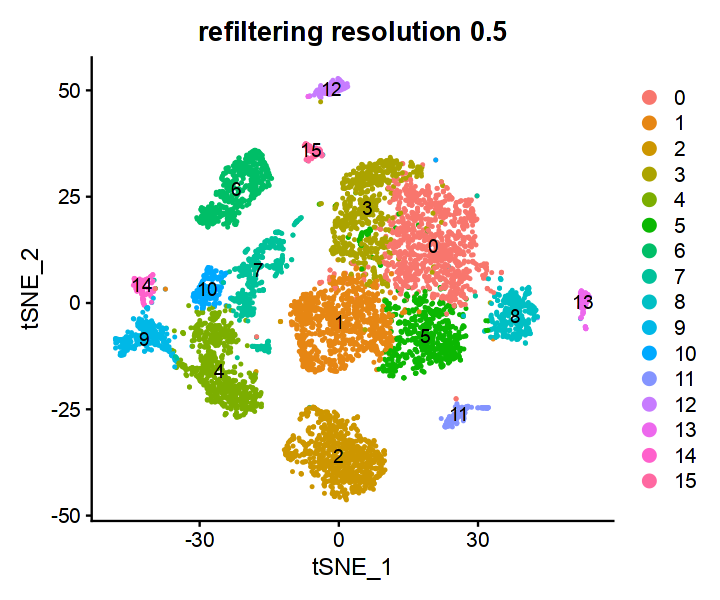

In [148]:
options(repr.plot.width = 6, repr.plot.height = 5)
DimPlot(merged_filt, 
        reduction = "tsne",
        group.by = "refilt_res.0.5", label=TRUE) + labs(title = "refiltering resolution 0.5")

In [149]:
Idents(merged_filt) <- "seurat_clusters"

#1) Define annotation mapping (names must match cluster IDs exactly)
celltype_fine <- c(
    "0" = "MonoMac", 
    "1" = "MonoMac", 
    "2" = "NK", 
    "3" = "MonoMac", 
    "4" = "CD8+T", 
    "5" = "MonoMac",
    "6" = "Neutrophil", 
    "7" = "CD8+T",
    "8" = "cDC2", 
    "9" = "CD4+T", 
    "10" = "CD8+T",
    "11" = "mRegDC", 
    "12" = "B", 
    "13" = "pDC", 
    "14" = "CD4+T", 
    "15" = "cDC1"
)

celltype_broad <- c(
    "0" = "CD11b+ TIM", 
    "1" = "CD11b+ TIM", 
    "2" = "NK", 
    "3" = "CD11b+ TIM", 
    "4" = "T", 
    "5" = "CD11b+ TIM",
    "6" = "CD11b+ TIM", 
    "7" = "T",
    "8" = "CD11b+ TIM", 
    "9" = "T", 
    "10" = "T",
    "11" = "mregDC", 
    "12" = "B", 
    "13" = "pDC", 
    "14" = "T", 
    "15" = "cDC1"
)

In [150]:
setdiff(levels(merged_filt), names(celltype_fine))

character(0)

In [151]:
setdiff(levels(merged_filt), names(celltype_broad))

character(0)

In [152]:
merged_filt$celltype_fine <- unname(celltype_fine[as.character(Idents(merged_filt))])
merged_filt$celltype_broad <- unname(celltype_broad[as.character(Idents(merged_filt))])

In [153]:
head(merged_filt)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,day,RNA_snn_res.0.3,seurat_clusters,refilt_res.0.5,SingleR_main,celltype_fine,celltype_broad
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<chr>,<chr>,<chr>
Day3_AAACCCACAGAAGCGT-1,day03,6319,1899,2.310492,Day3,1,3,3,Macrophages,MonoMac,CD11b+ TIM
Day3_AAACCCACAGCTTCGG-1,day03,10846,2735,2.636917,Day3,3,2,2,ILC,NK,NK
Day3_AAACCCATCAACGTGT-1,day03,1426,544,9.186536,Day3,7,6,6,Neutrophils,Neutrophil,CD11b+ TIM
Day3_AAACCCATCTGCTCTG-1,day03,15119,3407,2.215755,Day3,0,5,5,Macrophages,MonoMac,CD11b+ TIM
Day3_AAACGAATCCCGATCT-1,day03,6505,2183,2.997694,Day3,3,2,2,ILC,NK,NK
Day3_AAACGCTAGCGCCCAT-1,day03,6463,1616,2.661303,Day3,1,3,3,Macrophages,MonoMac,CD11b+ TIM
Day3_AAAGAACAGTGAGTTA-1,day03,6740,2251,3.635015,Day3,3,2,2,ILC,NK,NK
Day3_AAAGAACAGTGCTAGG-1,day03,20541,3603,5.131201,Day3,6,7,7,T cells,CD8+T,T
Day3_AAAGAACCAATAGAGT-1,day03,9158,2759,1.976414,Day3,1,0,0,Macrophages,MonoMac,CD11b+ TIM


In [154]:
Idents(merged_filt) <- "celltype_broad"

# 3. Visualization

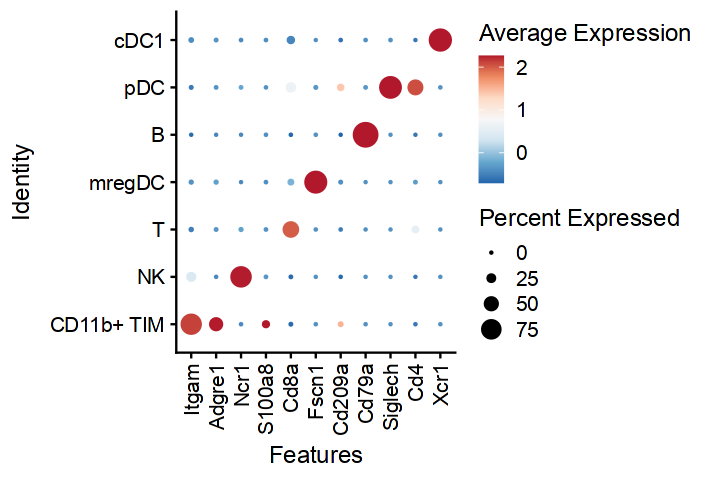

In [155]:
options(repr.plot.width = 6, repr.plot.height = 4)
cluster_specific_genes1 <- c(
    "Itgam",
    "Adgre1", #0 Macrophage/Monocyte
    "Ncr1", #1 NK
    "S100a8",#5 Neutrophil
    "Cd8a", #2 Cd8
    "Fscn1",  #8 cDC3/mRegDC
    "Cd209a",#6 cDC2 （cDC1（Xcr1）は ＊Itgamは発現してなさそう）  "Xcr1", # cDC1
    "Cd79a", #9 B
    "Siglech", #10 pDC
    "Cd4", # CD4+T
    "Xcr1"
)
DotPlot(merged_filt, features = cluster_specific_genes1, cols = "RdBu") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

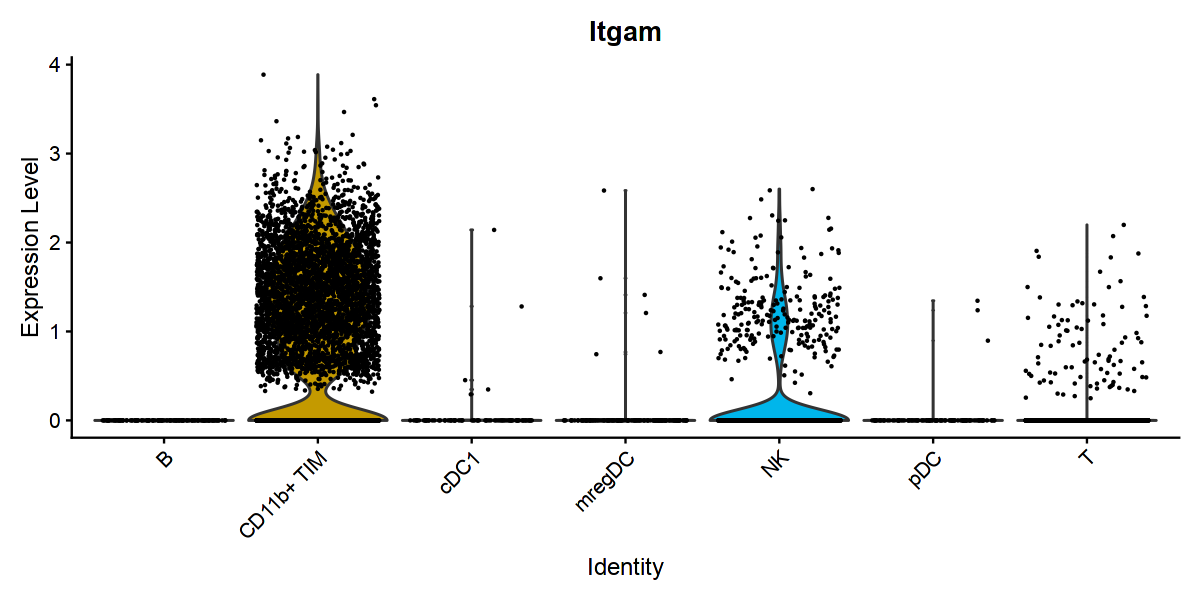

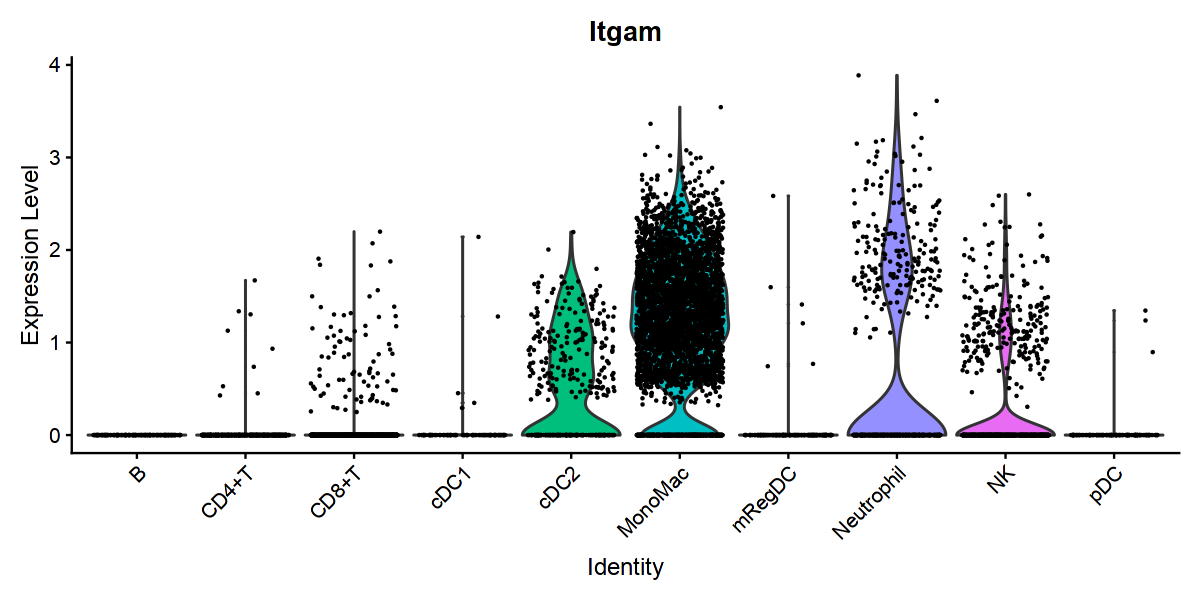

In [156]:
cluster_specific_genes1 <- c("Itgam")

options(repr.plot.width = 10,repr.plot.height = 5)
VlnPlot(merged_filt, features = cluster_specific_genes1, 
        ncol= 1, pt.size=0.01, group.by='celltype_broad')+NoLegend()

options(repr.plot.width = 10,repr.plot.height = 5)
VlnPlot(merged_filt, features = cluster_specific_genes1,
        ncol= 1, pt.size=0.01, group.by='celltype_fine')+NoLegend()

## a. Heatmap

In [157]:
celltype_markers <- FindAllMarkers(merged_filt, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)

Calculating cluster CD11b+ TIM

Calculating cluster NK

Calculating cluster T

Calculating cluster mregDC

Calculating cluster B

Calculating cluster pDC

Calculating cluster cDC1



In [158]:
head(celltype_markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Emilin2,0,5.770976,0.860,0.049,0,CD11b+ TIM,Emilin2
Cd14,0,6.542376,0.881,0.071,0,CD11b+ TIM,Cd14
Alox5ap,0,3.606804,0.908,0.108,0,CD11b+ TIM,Alox5ap
Spi1,0,3.772772,0.918,0.132,0,CD11b+ TIM,Spi1
Ccr1,0,6.114668,0.823,0.040,0,CD11b+ TIM,Ccr1
Mpeg1,0,2.910419,0.871,0.105,0,CD11b+ TIM,Mpeg1


In [159]:
celltype_markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() ->  top_markers_aggregate

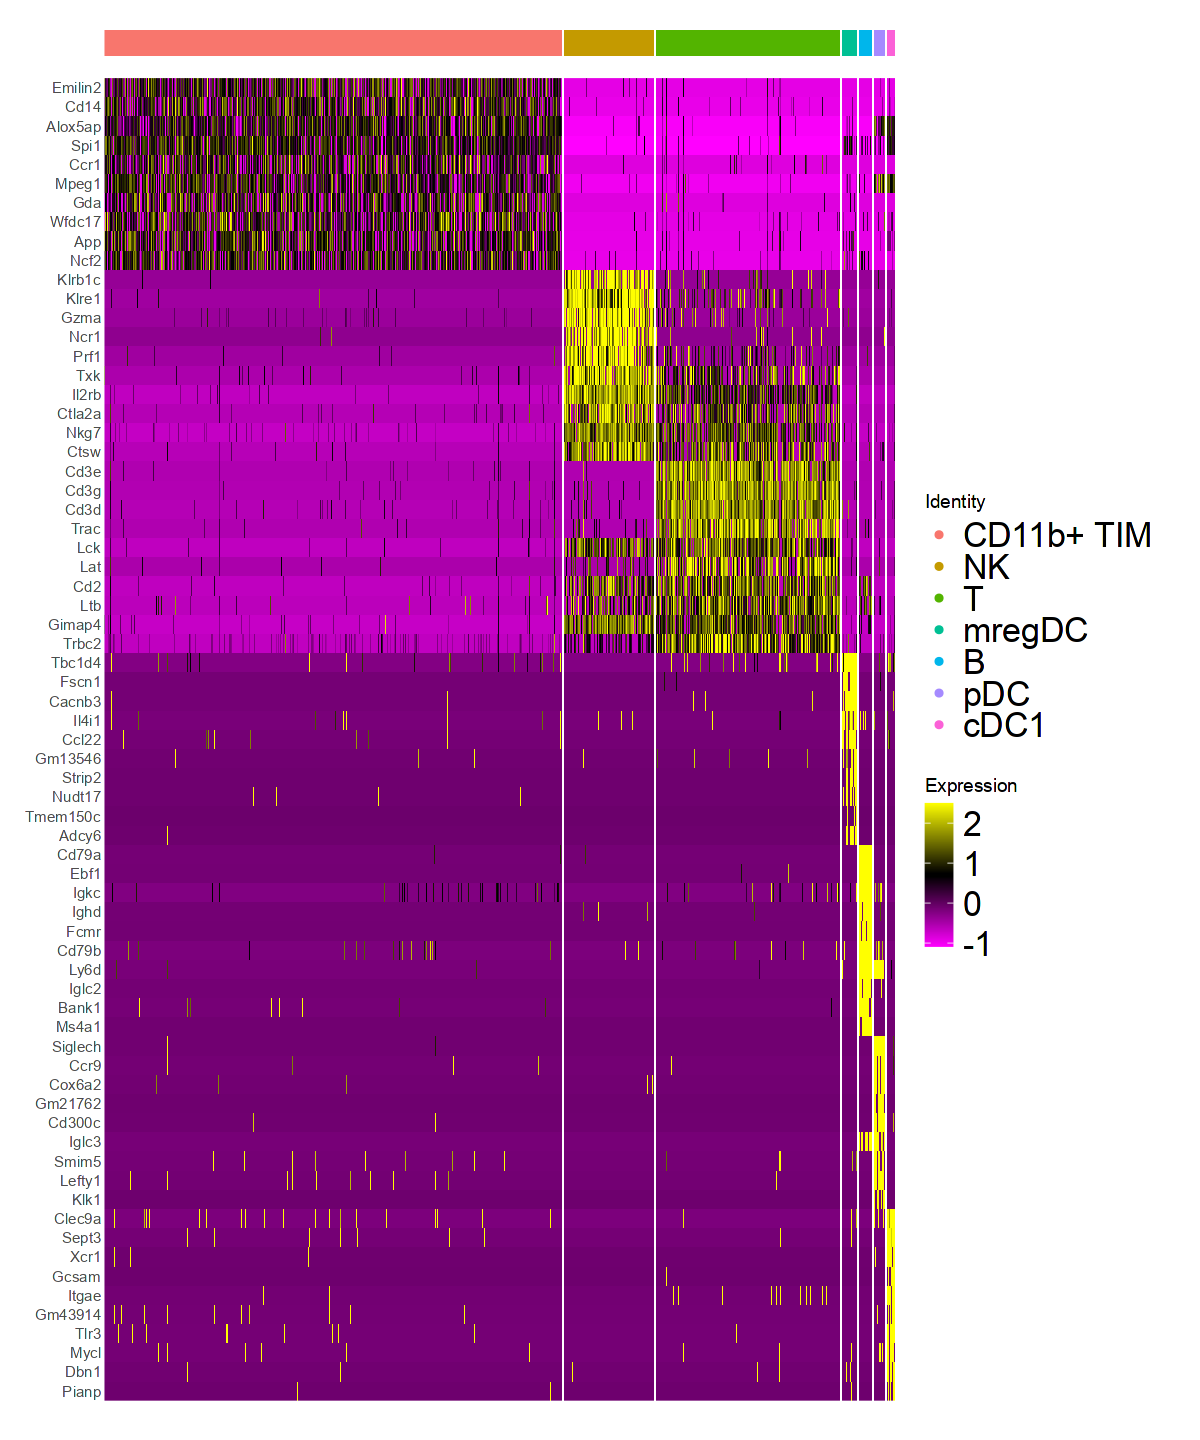

In [160]:
options(repr.plot.width = 10, repr.plot.height = 12)
p1 <- DoHeatmap(merged_filt, features = top_markers_aggregate$gene,
                  #slot='scale.data',
                  angle = 90, 
                  size=30,
                  label=FALSE)+
theme(legend.text = element_text(size = 20))

p1

ggsave(file.path(dir_fig,"01_annotation_heatmap.jpeg"), plot = p1, width = 10, height = 12, dpi = 1200)
ggsave(file.path(dir_fig,"01_annotation_heatmap.pdf"), plot = p1, width = 10, height = 12, dpi = 1200)

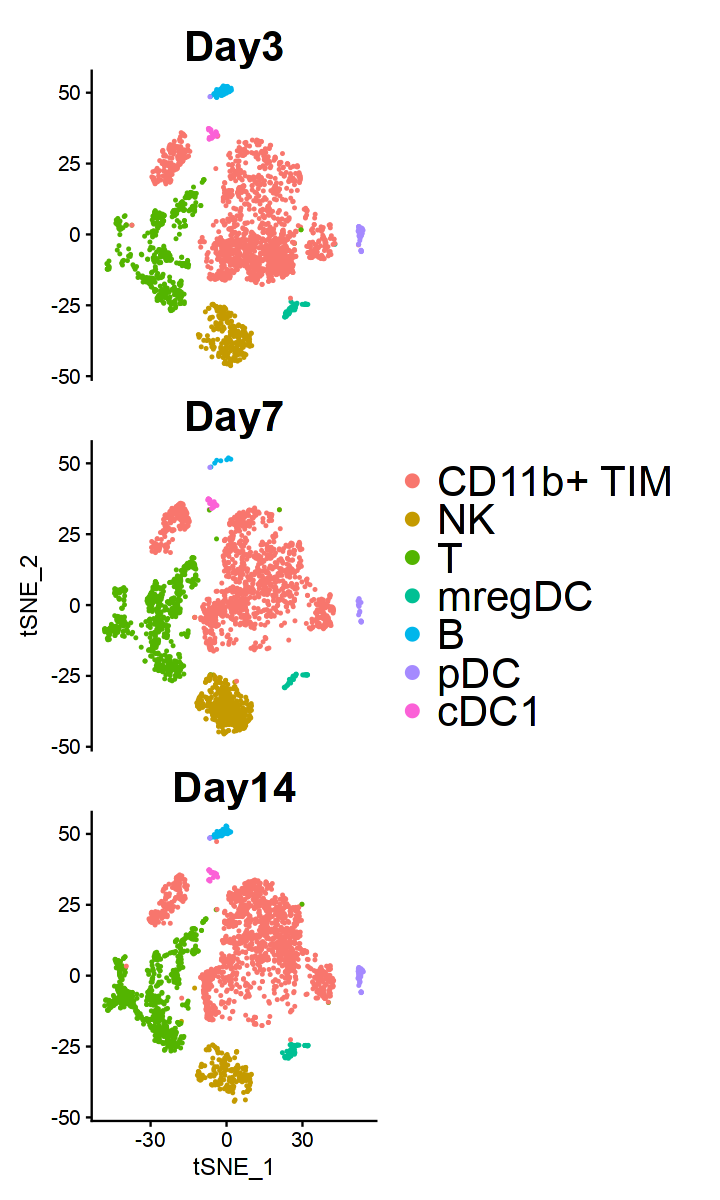

In [161]:
options(repr.plot.width = 6, repr.plot.height = 10)
p2 <- DimPlot(merged_filt, reduction = "tsne", label = FALSE, split.by='day', ncol=1) + 
theme(legend.text = element_text(size = 25), strip.text = element_text(size = 25))
#+scale_color_brewer(palette = "Set1")

p2

ggsave(file.path(dir_fig,"02_overall_tsne_v.jpeg"), plot = p2, width = 6, height = 10, dpi = 300)
ggsave(file.path(dir_fig,"02_overall_tsne_v.pdf"), plot = p2, width = 6, height = 10, dpi = 300)

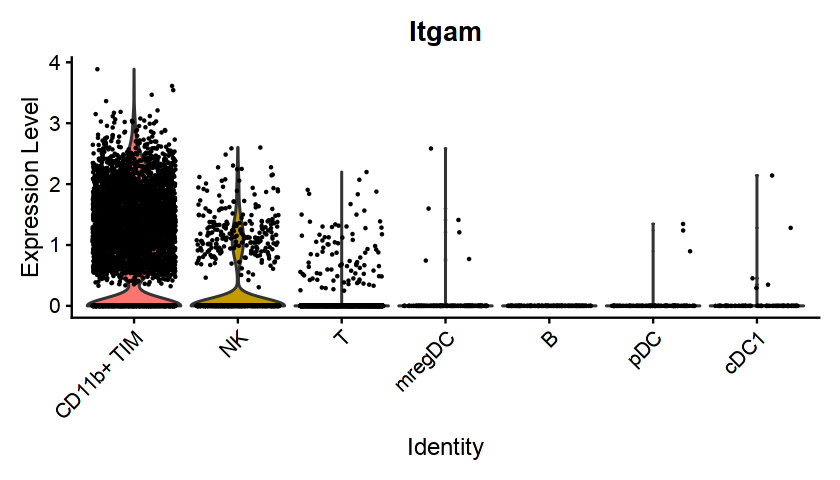

In [162]:
cluster_specific_genes2 <- c("Itgam")
options(repr.plot.width = 7,repr.plot.height = 4)
p3 <- VlnPlot(merged_filt, features = cluster_specific_genes2, ncol=1, pt.size=0.01)+NoLegend()
p3

ggsave(file.path(dir_fig,"03_MDSC_marker.jpeg"), plot = p3, width = 7, height = 4, dpi = 1200)
ggsave(file.path(dir_fig,"03_MDSC_marker.pdf"), plot = p3, width = 7, height = 4, dpi = 1200)

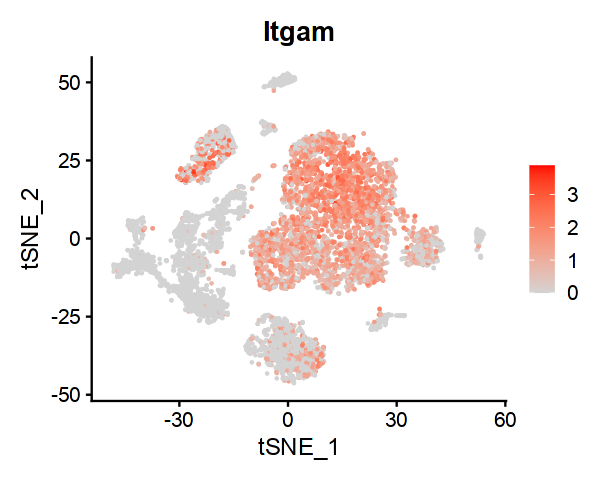

In [163]:
options(repr.plot.width = 5, repr.plot.height = 4)
p3_2 <- FeaturePlot(merged_filt, features = c("Itgam"), 
            reduction = "tsne", pt.size = 0.1, ncol=1, cols = c("lightgrey", "red"))
p3_2

ggsave(file.path(dir_fig,"03_MDSC_feature.jpeg"), plot = p3_2, width = 5, height = 4, dpi = 1200)
ggsave(file.path(dir_fig,"03_MDSC_feature.pdf"), plot = p3_2, width = 5, height = 4, dpi = 1200)

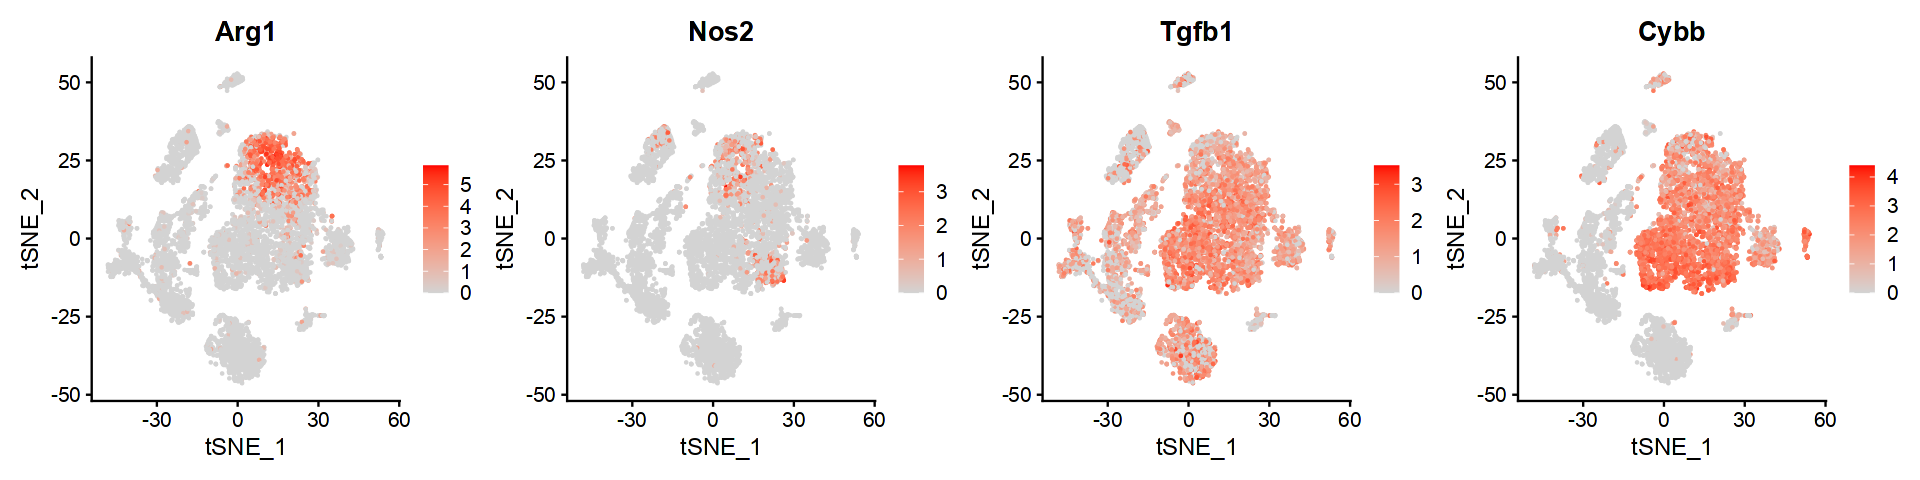

In [164]:
cluster_specific_genes1 <- c("Arg1", "Nos2", "Tgfb1", "Cybb")

options(repr.plot.width = 16,repr.plot.height = 4)
p4 <- FeaturePlot(merged_filt, features = cluster_specific_genes1, reduction = "tsne", pt.size=0.1, ncol=4, cols = c("lightgrey", "red"))
p4

ggsave(file.path(dir_fig,"04_sup_marker_feature.jpeg"), plot = p4, width = 16, height = 4, dpi = 300)
ggsave(file.path(dir_fig,"04_sup_marker_feature.pdf"), plot = p4, width = 16, height = 4, dpi = 300)

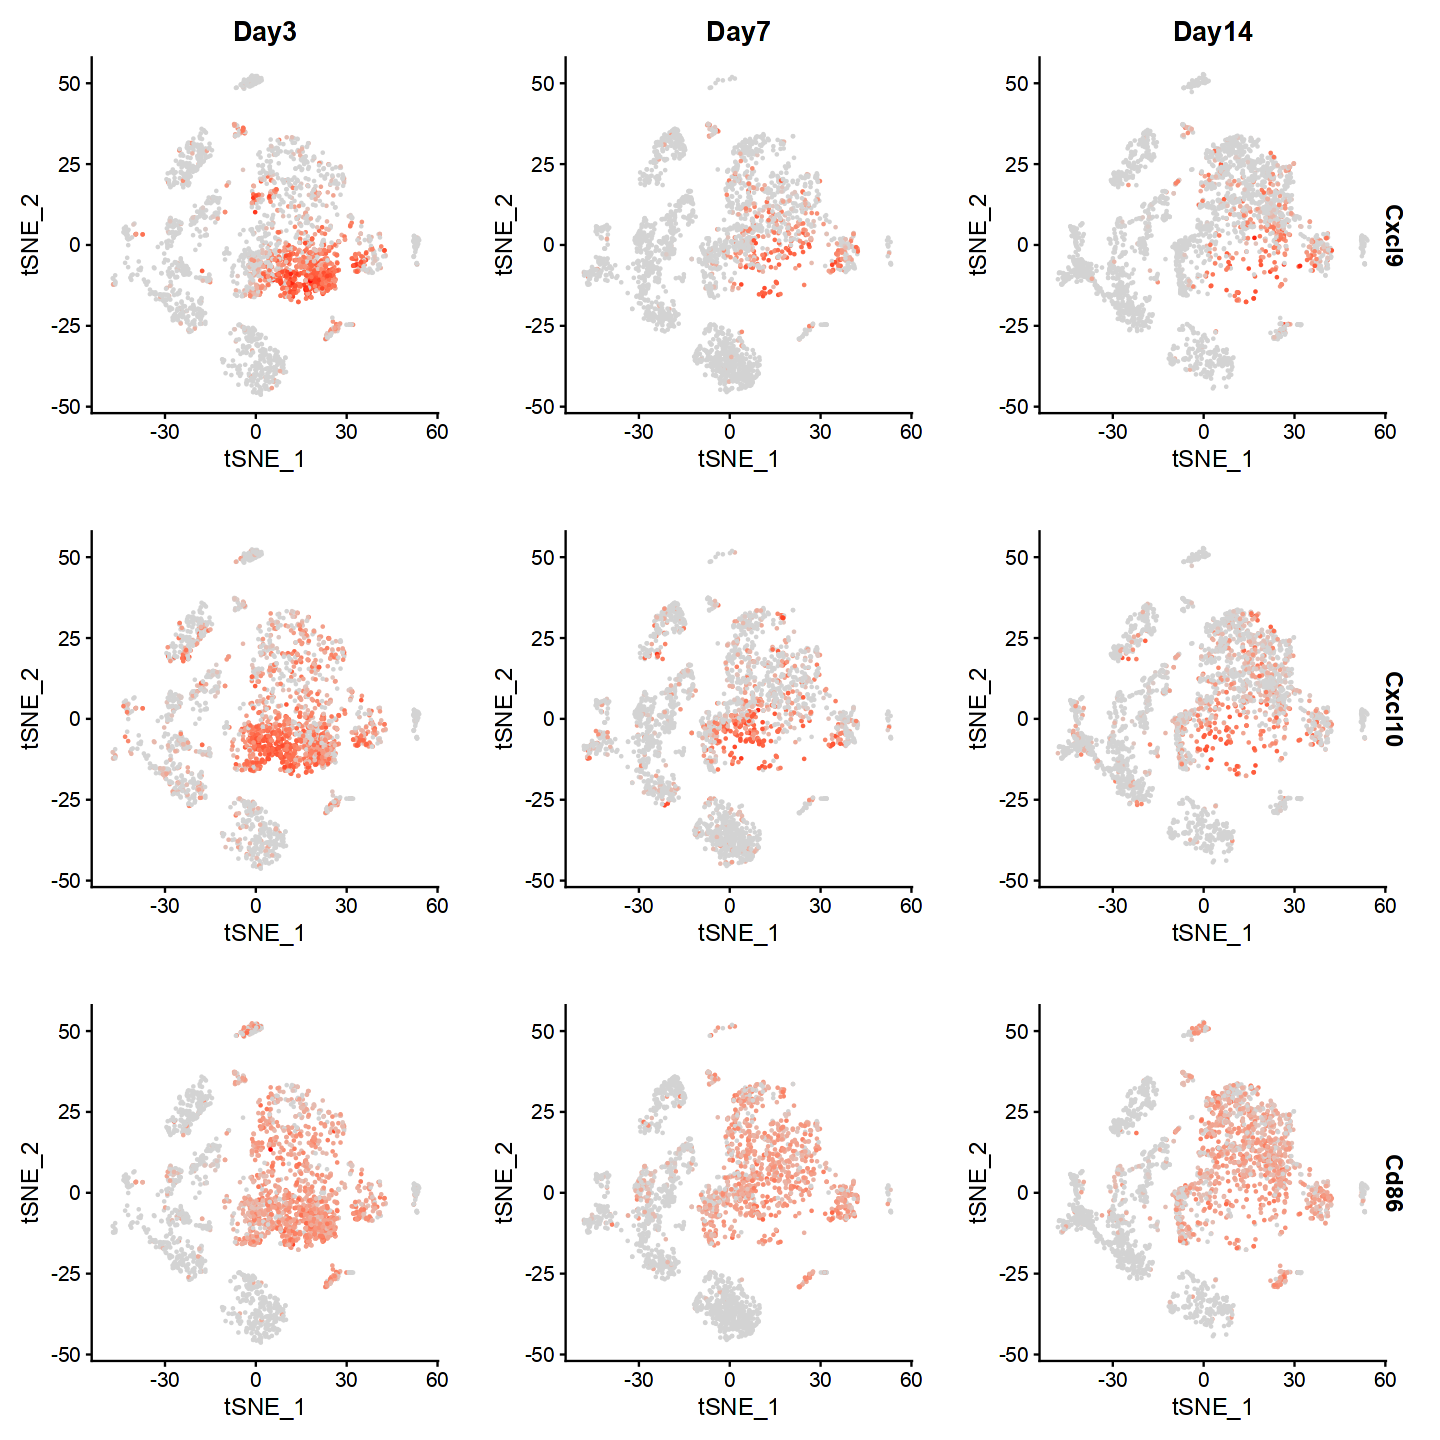

In [165]:
cluster_specific_genes1 <- c("Cxcl9", "Cxcl10","Cd86")

options(repr.plot.width = 12,repr.plot.height = 12)
p5 <- FeaturePlot(merged_filt, features = cluster_specific_genes1, 
                  split.by='day',
                  reduction = "tsne", pt.size=0.1, ncol=4, cols = c("lightgrey", "red"))
p5

ggsave(file.path(dir_fig,"05_act_marker_feature.jpeg"), plot = p5, width = 12, height = 12, dpi = 1200)
ggsave(file.path(dir_fig,"05_act_marker_feature.pdf"), plot = p5, width = 12, height = 12, dpi = 1200)

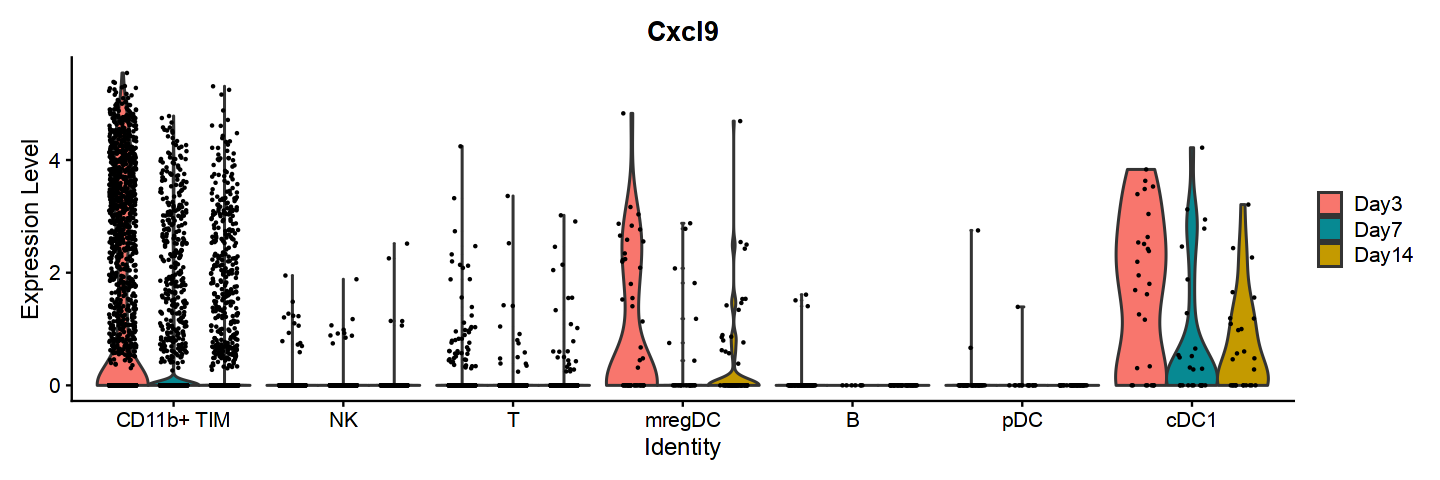

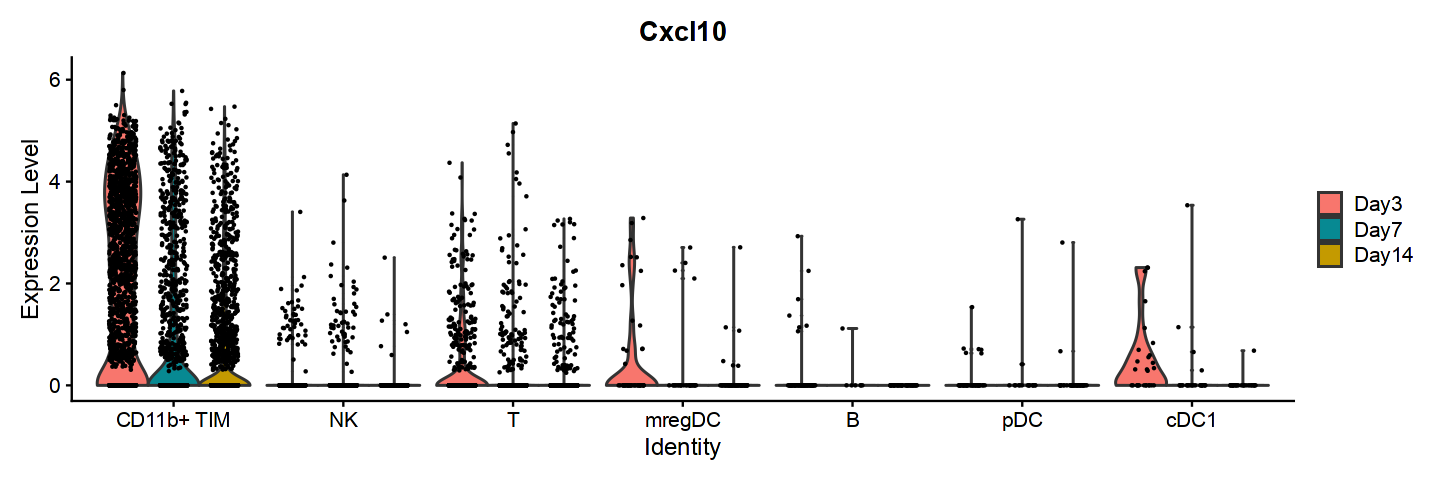

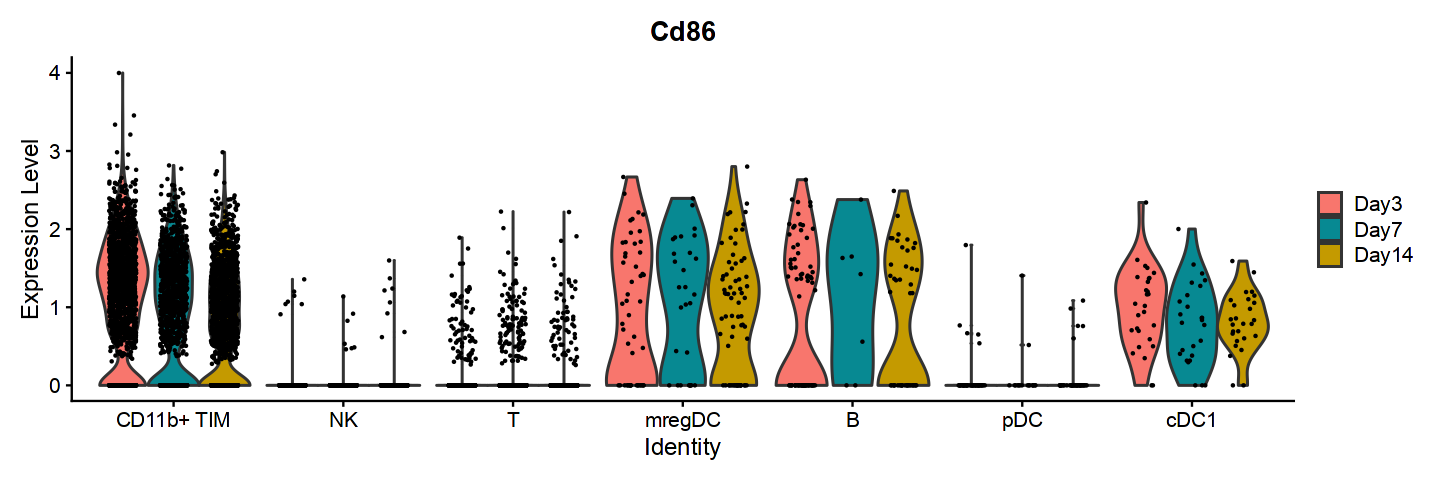

In [166]:
cluster_specific_genes1 <- c("Cxcl9")
options(repr.plot.width = 12,repr.plot.height = 4)
p6_1 <- VlnPlot(merged_filt, features = cluster_specific_genes1, ncol=1, pt.size=0.01, split.by='day')+ 
theme(axis.text.x = element_text(angle = 0, hjust=0.5))
p6_1

cluster_specific_genes1 <- c("Cxcl10")
p6_2 <- VlnPlot(merged_filt, features = cluster_specific_genes1, ncol=1, pt.size=0.01, split.by='day')+
theme(axis.text.x = element_text(angle = 0, hjust=0.5))

p6_2

cluster_specific_genes1 <- c("Cd86")
p6_3 <- VlnPlot(merged_filt, features = cluster_specific_genes1, ncol=1, pt.size=0.01, split.by='day')+
theme(axis.text.x = element_text(angle = 0, hjust=0.5))
p6_3

ggsave(file.path(dir_fig,"06_1_Vlnplot_feature1.pdf"), plot = p6_1, width = 10, height = 4, dpi = 300)
ggsave(file.path(dir_fig,"06_2_Vlnplot_feature2.pdf"), plot = p6_2, width = 10, height = 4, dpi = 300)
ggsave(file.path(dir_fig,"06_3_Vlnplot_feature3.pdf"), plot = p6_3, width = 10, height = 4, dpi = 300)

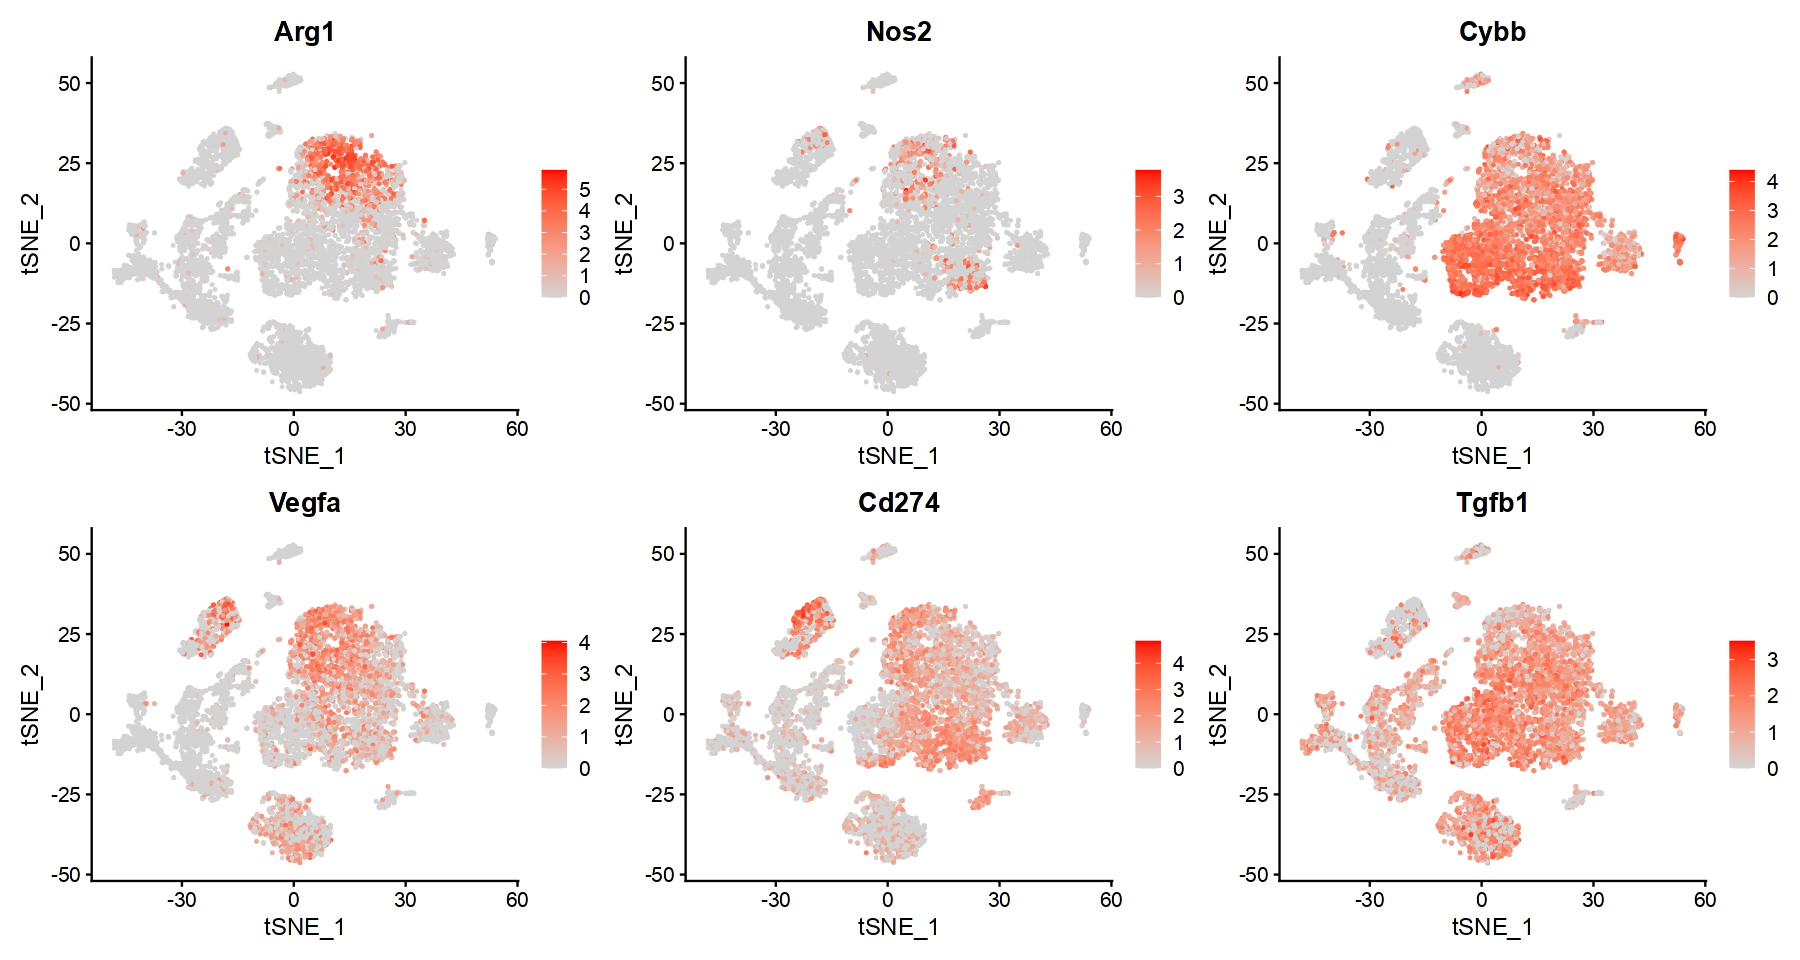

In [167]:
options(repr.plot.width = 15, repr.plot.height = 8)
suppression_marker = c(
    "Arg1","Nos2", "Cybb" , "Vegfa",      
    "Cd274", "Tgfb1"
)

p7 <- FeaturePlot(merged_filt, features = suppression_marker, ncol = 3, reduction='tsne',
            cols = c("lightgrey", "red"))

p7 
ggsave(file.path(dir_fig,"07_suppression_feature.pdf"), plot = p7, width = 15, height = 8, dpi = 300)

In [168]:
saveRDS(merged_filt, file = file.path(dir_int, "merged_filt.rds"))